In [6]:
import pandas as pd
import os

# 1. Figure out where we are
current_dir = os.getcwd()

# 2. Find the project root (handling both VS Code and Terminal behavior)
if "notebooks" in current_dir:
    root_path = os.path.dirname(current_dir) # Go up to customer_support_intent
else:
    root_path = current_dir # You are already at the root

# 3. Create the path to your training data
# We use 'data_path' consistently here
data_path = os.path.join(root_path, 'data', 'processed', 'train.csv')

# 4. Load the file
if os.path.exists(data_path):
    train_df = pd.read_csv(data_path)
    print(" Success! Data loaded.")
    print(f"Total training rows: {len(train_df)}")
    print("\nFirst 5 rows of your data:")
    display(train_df.head())
else:
    print(f" Still can't find it at: {data_path}")
    print(f"Current directory is: {current_dir}")

 Success! Data loaded.
Total training rows: 6328

First 5 rows of your data:


,text,intent
0,where can I check the damn withdrawal charges?,check_cancellation_fee
1,i cannot check the refund current status,track_refund
2,I don't know how I can see the termination fee,check_cancellation_fee
3,need help seeing in what situations can i ask ...,check_refund_policy
4,canceling order {{Order Number}},cancel_order


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9540\1048679280.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y='intent', palette='viridis',


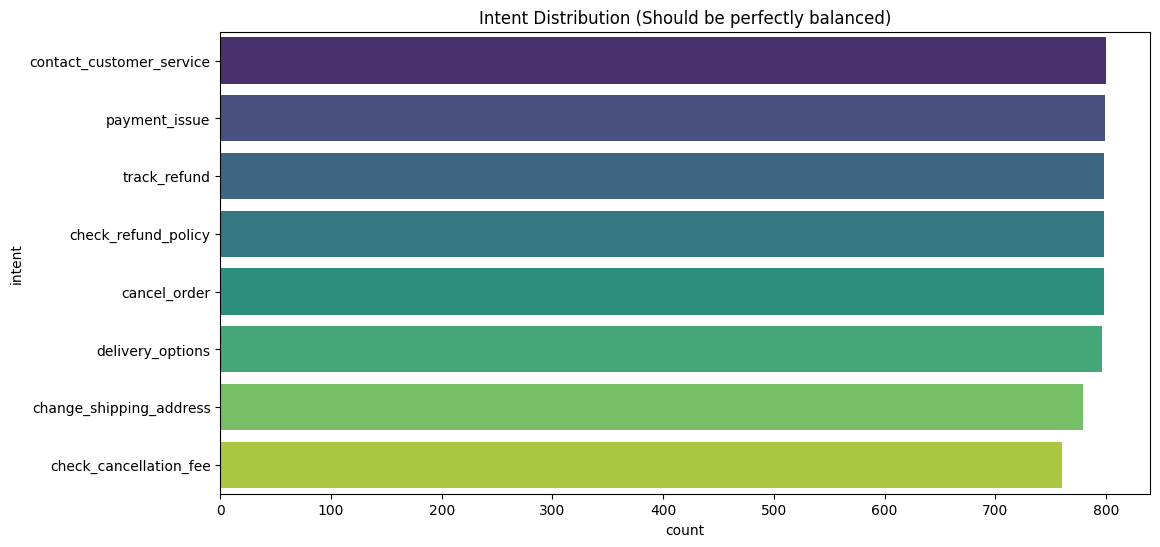

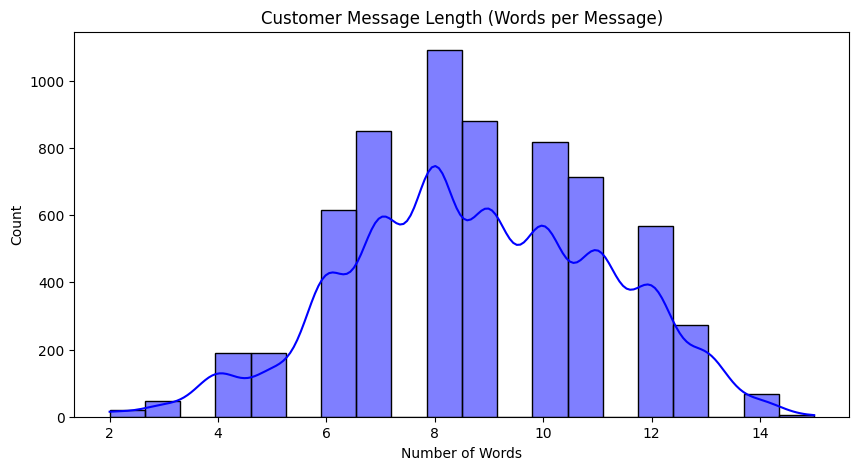

Average words: 8.78
95th percentile length: 13.00


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Intent Distribution: Proving the 'Stratified Split' worked
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='intent', palette='viridis', 
              order=train_df['intent'].value_counts().index)
plt.title('Intent Distribution (Should be perfectly balanced)')
plt.show()

# 2. Text Length Analysis: Determining 'max_length'
# We count words to see how 'long' our input sequences are
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=20, kde=True, color='blue')
plt.title('Customer Message Length (Words per Message)')
plt.xlabel('Number of Words')
plt.show()

print(f"Average words: {train_df['word_count'].mean():.2f}")
print(f"95th percentile length: {train_df['word_count'].quantile(0.95):.2f}")

In [10]:
from transformers import AutoTokenizer

# 1. Load the tokenizer that matches our model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 2. Grab a sample message
sample = train_df['text'].iloc[0]

# 3. See how it is encoded
tokens = tokenizer.tokenize(sample)
ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Human Text: {sample}")
print(f"AI Tokens:  {tokens}")
print(f"Token IDs: {ids}")

Human Text: where can I check the damn withdrawal charges?
AI Tokens:  ['where', 'can', 'i', 'check', 'the', 'damn', 'withdrawal', 'charges', '?']
Token IDs: [2073, 2064, 1045, 4638, 1996, 4365, 10534, 5571, 1029]
